# Análise Exploratória — Heart Disease (UCI)

Objetivo: entender os dados antes de modelar.
- Volume e estrutura
- Qualidade (valores faltantes, tipos)
- Distribuição das variáveis e do alvo

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier
import mlflow
import mlflow.sklearn
from fairlearn.metrics import MetricFrame, false_negative_rate

print("Bibliotecas importadas")
print("pandas:", pd.__version__)

Bibliotecas importadas
pandas: 3.0.5


In [2]:
from ucimlrepo import fetch_ucirepo

# Baixa o dataset Heart Disease do repositório UCI (id=45)
heart_disease = fetch_ucirepo(id=45)

# Separa as variáveis preditoras (X) e o alvo (y)
X = heart_disease.data.features
y = heart_disease.data.targets

print("Download concluído")
print("Formato de X (linhas, colunas):", X.shape)
print("Formato de y (linhas, colunas):", y.shape)

Download concluído
Formato de X (linhas, colunas): (303, 13)
Formato de y (linhas, colunas): (303, 1)


In [3]:
# Mostra as 5 primeiras linhas das variáveis preditoras
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [4]:
#informações da matriz
X.info()
X.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

In [5]:
# Ver os valores únicos do alvo e quantas vezes cada um aparece
print("Formato de y:", y.shape)
print("\nContagem de cada valor no alvo:")
print(y.value_counts())

Formato de y: (303, 1)

Contagem de cada valor no alvo:
num
0      164
1       55
2       36
3       35
4       13
Name: count, dtype: int64


In [6]:
# Transformar o alvo multiclasse (0-4) em binário (0 = sem doença, 1 = com doença)
# Qualquer valor >= 1 vira 1
y_binario = (y['num'] >= 1).astype(int)

# Conferir o resultado
print("Distribuição do alvo binário:")
print(y_binario.value_counts())
print("\nProporção:")
print(y_binario.value_counts(normalize=True))

Distribuição do alvo binário:
num
0    164
1    139
Name: count, dtype: int64

Proporção:
num
0    0.541254
1    0.458746
Name: proportion, dtype: float64


In [7]:
#Descreve informações detalhadas do DataFrame

X.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


# Coleta de dados até aqui 

Verificamos o dataframe retornado pelo UCI. São 303 Pacientes que serão verificados afim de buscar problemas do coração. Vimos que faltam 6 dados: 4 em ca e 2 em thal. Já temos o describe dos dados. Iremos fazer uma análise visual das variáveis, e separar os dados para treino/teste


In [8]:
#Fazendo o EDA

X_eda = X.copy()
X_eda["doente"] = y_binario
X_eda.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,doente
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


<Axes: xlabel='oldpeak', ylabel='Count'>

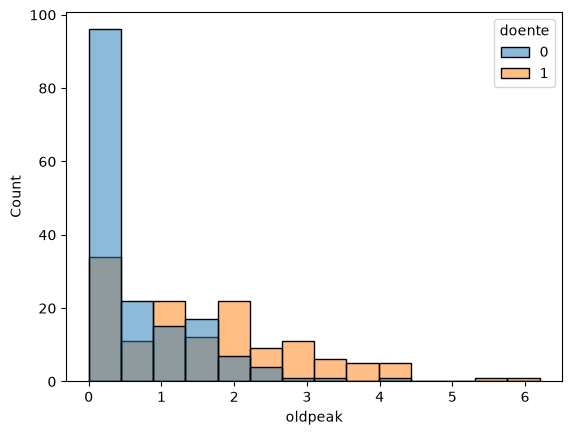

In [9]:
#Fazer histograma

sns.histplot(data=X_eda, x='oldpeak', hue="doente")

Feito a análise gráfica, vou verificado alguns dados de algumas variáveis. age >, thalach <, oldpeak >, risco de doença >


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binario,
    test_size = 0.2,
    random_state = 42,
    stratify = y_binario
)

print("train", X_train.shape)
print("test", X_test.shape)

train (242, 13)
test (61, 13)


In [11]:
num_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
cat_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()), 
    ("modelo", LogisticRegression(random_state=42, max_iter=1000))])

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
     ("scaler", StandardScaler())])
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("OHE", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)])

pipeline_completo = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(random_state=42, max_iter=1000))])


In [12]:
pipeline.fit(X_train, y_train)
pipeline_completo.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere no

In [13]:
y_pred = pipeline.predict(X_test)
y_completa_pred = pipeline_completo.predict(X_test)

In [14]:
acuracia = accuracy_score(y_test, y_pred)
acuracia_completa = accuracy_score(y_test, y_completa_pred)
print("Acurácia:", acuracia)
print("Acurácia completa:", acuracia_completa)

Acurácia: 0.8688524590163934
Acurácia completa: 0.8852459016393442


In [15]:
matriz = confusion_matrix(y_test, y_pred)
matriz_completa = confusion_matrix(y_test, y_completa_pred)
print(matriz)
print(matriz_completa)

[[27  6]
 [ 2 26]]
[[28  5]
 [ 2 26]]


In [16]:
print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_completa_pred))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [17]:
scores_lr = cross_val_score(
    pipeline_completo,
    X_train, y_train,
    cv=5,
    scoring="recall"
)

print("Notas dos 5 folds:", scores_lr)
print("Média:", scores_lr.mean())
print("Desvio:", scores_lr.std())

Notas dos 5 folds: [0.86956522 0.68181818 0.86363636 0.77272727 0.68181818]
Média: 0.7739130434782607
Desvio: 0.08266068678052056


# Resultados do primeiro modelo:

Baseline (Regressão Logística): acurácia 87%, recall(doente) 93%, precision(doente) 81%, F1 0.87. 2 falsos negativos. Esta é a régua a superar

OneHot Encoder superou a Baseline: acurácia de 89%, recall manteve, precision subiu para 84%, F1 subiu para 89%. Mantiveram os 2 falsos negativos

Na validação cruzada, descobrimos 77% de acurácia com +-0.08 de Desvio. réguapara outros modelos bater

In [18]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
     ("scaler", StandardScaler())])
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("OHE", OneHotEncoder(handle_unknown="ignore"))])

preprocessor_rf = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)])

pipeline_rf = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("model", RandomForestClassifier(random_state=42))])

In [19]:
pipeline_rf.fit(X_train, y_train)

y_rf = pipeline_rf.predict(X_test)
acuracia_rf = accuracy_score(y_test, y_rf)
print("Acurácia RandomForest:", acuracia_rf)

Acurácia RandomForest: 0.8688524590163934


In [20]:
matriz = confusion_matrix(y_test, y_rf)

In [29]:
print(classification_report(y_test, y_rf))
scores_rf = cross_val_score(
    pipeline_rf,
    X_train, y_train,
    cv=5,
    scoring="recall"
)

print("Notas dos 5 folds:", scores_lr)
print("Média:", scores_lr.mean())
print("Desvio:", scores_lr.std())

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

Notas dos 5 folds: [0.86956522 0.68181818 0.86363636 0.77272727 0.68181818]
Média: 0.7739130434782607
Desvio: 0.08266068678052056


# Resultados do segundo modelo:

RandomForest empatou com LinearRegression, sendo até inferior a ele (0.7652 vs 0.7739)

In [22]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
     ("scaler", StandardScaler())])
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("OHE", OneHotEncoder(handle_unknown="ignore"))])

preprocessor_rf = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)])

pipeline_mlp = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("model", MLPClassifier(random_state=42, max_iter=1000))])

In [23]:
pipeline_mlp.fit(X_train, y_train)

y_mlp = pipeline_rf.predict(X_test)
acuracia_mlp = accuracy_score(y_test, y_mlp)
print("Acurácia MLP:", acuracia_mlp)

Acurácia MLP: 0.8688524590163934


In [28]:
print(classification_report(y_test, y_rf))
scores_mlp = cross_val_score(
    pipeline_mlp,
    X_train, y_train,
    cv=5,
    scoring="recall"
)

print("Notas dos 5 folds:", scores_lr)
print("Média:", scores_lr.mean())
print("Desvio:", scores_lr.std())

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

Notas dos 5 folds: [0.86956522 0.68181818 0.86363636 0.77272727 0.68181818]
Média: 0.7739130434782607
Desvio: 0.08266068678052056


# Resultado final

Os três modelos empataram. O LR foi escolhido por ter menos complexidade e ser menos instável que o MLP 

In [25]:
y_final = pipeline_completo.predict(X_test)
print(classification_report(y_test, y_final))
scores_lr = cross_val_score(
    pipeline_completo,
    X_train, y_train,
    cv=5,
    scoring="recall"
)

print("Notas dos 5 folds:", scores_lr)
print("Média:", scores_lr.mean())
print("Desvio:", scores_lr.std())

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61

Notas dos 5 folds: [0.86956522 0.68181818 0.86363636 0.77272727 0.68181818]
Média: 0.7739130434782607
Desvio: 0.08266068678052056


# Inicio do MLFlow

In [32]:
mlflow.set_tracking_uri("sqlite:////home/casnav/tech-challenge/mlflow.db")
mlflow.set_experiment("heart-disease")
models = ["LogisticRegression", "RandomForest", "MLP"]
for model in models:
    with mlflow.start_run(run_name=model):
        if model == "LogisticRegression":
            pipeline_completo.fit(X_train, y_train)
            mlflow.log_param("modelo", "LogisticRegression")
            mlflow.log_metric("recall_cv", scores_lr.mean())
            mlflow.sklearn.log_model(pipeline_completo, name="LogisticRegression", serialization_format="pickle")
        elif model == "RandomForest":
            pipeline_rf.fit(X_train, y_train)
            mlflow.log_param("modelo", "RandomForest")
            mlflow.log_metric("recall_cv", scores_rf.mean())
            mlflow.sklearn.log_model(pipeline_rf, name="RandomForest", serialization_format="pickle")
        else:
            pipeline_mlp.fit(X_train, y_train)
            mlflow.log_param("modelo", "MLP")
            mlflow.log_metric("recall_cv", scores_mlp.mean())
            mlflow.sklearn.log_model(pipeline_mlp, name="MLP", serialization_format="pickle")

2026/09/12 11:03:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/12 11:03:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/12 11:03:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

# Inicio da Fase 3

Iniciar a fase de Governança e auditoria 

In [41]:
sensitive_sex = X_test["sex"]
print("Tamanho y_test:", len(y_test))
print("Tamanho y_pred:", len(y_pred))
print("Tamanho sensitive_sex:", len(sensitive_sex))
print("\nValores em sex:", sensitive_sex.value_counts())

Tamanho y_test: 61
Tamanho y_pred: 61
Tamanho sensitive_sex: 61

Valores em sex: sex
1    41
0    20
Name: count, dtype: int64


In [42]:
mf = MetricFrame(
    metrics=false_negative_rate,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_sex
)

print("FNR geral (todos os pacientes):", mf.overall)
print("\nFNR por grupo de sexo:")
print(mf.by_group)

FNR geral (todos os pacientes): 0.07142857142857142

FNR por grupo de sexo:
sex
0    0.142857
1    0.047619
Name: false_negative_rate, dtype: float64


In [43]:
# Quantos doentes reais em cada grupo (base da FNR)
import pandas as pd

check = pd.DataFrame({"sex": sensitive_sex, "doente_real": y_test})
print(check.groupby("sex")["doente_real"].agg(["sum", "count"]))

     sum  count
sex            
0      7     20
1     21     41


In [44]:
# --- Governance as Code: verificação de disparidade de FNR ---

fnr_por_grupo = mf.by_group
disparidade = fnr_por_grupo.max() - fnr_por_grupo.min()

LIMIAR_DISPARIDADE = 0.10   # decisão de política, não técnica

print(f"FNR por grupo:\n{fnr_por_grupo}\n")
print(f"Disparidade (max - min): {disparidade:.3f}")
print(f"Limiar aceitável:        {LIMIAR_DISPARIDADE:.3f}")

if disparidade > LIMIAR_DISPARIDADE:
    print("\n❌ REPROVADO: disparidade acima do limiar. Modelo não deve ser registrado.")
else:
    print("\n✅ APROVADO: disparidade dentro do limite aceitável.")

FNR por grupo:
sex
0    0.142857
1    0.047619
Name: false_negative_rate, dtype: float64

Disparidade (max - min): 0.095
Limiar aceitável:        0.100

✅ APROVADO: disparidade dentro do limite aceitável.


In [45]:
# --- Salvaguarda: a taxa é confiável? (tamanho da base por grupo) ---

# Doentes reais por grupo = a base sobre a qual a FNR é calculada
doentes_por_grupo = check.groupby("sex")["doente_real"].sum()

MIN_CASOS_CONFIAVEL = 10   # abaixo disso, a taxa é instável demais p/ cravar

print("Doentes reais por grupo (base da FNR):")
print(doentes_por_grupo, "\n")

for grupo, n_doentes in doentes_por_grupo.items():
    if n_doentes < MIN_CASOS_CONFIAVEL:
        print(f"⚠️  Grupo sex={grupo}: só {n_doentes} doentes reais. "
              f"FNR instável — interpretar com cautela, não é conclusiva.")

Doentes reais por grupo (base da FNR):
sex
0     7
1    21
Name: doente_real, dtype: int64 

⚠️  Grupo sex=0: só 7 doentes reais. FNR instável — interpretar com cautela, não é conclusiva.


In [53]:
model_card = """
# Model Card — Detecção de Doença Cardíaca (FIAP HealthCare Plus)

## Detalhes do Modelo
- Algoritmo: Logistic Regression. Empatou em recall (~0.77 na CV) com MLP e Random Forest. Escolhida por parcimônia e interpretabilidade — importante em saúde, onde a decisão precisa ser explicável.
- Versão / data: v1.0 - 12/09/2026
- Dataset de treino: Usado o dataset de Hearth Disease da UCI, como 303 pacientes

## Uso Pretendido
- Para que serve: Triagem médica preliminar para doenças cardíacas
- Para que NÃO serve / fora de escopo: Qualquer outro tipo de doença e para uso pediátrico

## Métricas de Performance
- Global: Acurácia: 0.869, Classe 1 (doente): precision: 0.812 recall: 0.93 f1-score 0.867 support: 28 
- Nota honesta sobre CV vs teste: CV dá ~0.77, o 0.93 do teste é recorte favorável

## Análise de Fairness
- Atributo sensível auditado: "sex"
- FNR por grupo: 0: 0.14, 1: 0,04
- Disparidade e limiar: Disparidade de 0,095 e aceitável 0,1

## Limitações Conhecidas
- A auditoria indicou FNR mais alta no grupo feminino (0.143 vs 0.048), mas baseada em apenas 7 doentes reais — é um indício a reavaliar, não uma disparidade confirmada.; 
- Tem-se necessidade de testes em mais populações
"""

from pathlib import Path
caminho = Path("../models/model_card.md")
caminho.write_text(model_card, encoding="utf-8")
print(f"Model Card salvo em: {caminho.resolve()}")
print(model_card)

Model Card salvo em: /home/casnav/tech-challenge/models/model_card.md

# Model Card — Detecção de Doença Cardíaca (FIAP HealthCare Plus)

## Detalhes do Modelo
- Algoritmo: Logistic Regression. Empatou em recall (~0.77 na CV) com MLP e Random Forest. Escolhida por parcimônia e interpretabilidade — importante em saúde, onde a decisão precisa ser explicável.
- Versão / data: v1.0 - 12/09/2026
- Dataset de treino: Usado o dataset de Hearth Disease da UCI, como 303 pacientes

## Uso Pretendido
- Para que serve: Triagem médica preliminar para doenças cardíacas
- Para que NÃO serve / fora de escopo: Qualquer outro tipo de doença e para uso pediátrico

## Métricas de Performance
- Global: Acurácia: 0.869, Classe 1 (doente): precision: 0.812 recall: 0.93 f1-score 0.867 support: 28 
- Nota honesta sobre CV vs teste: CV dá ~0.77, o 0.93 do teste é recorte favorável

## Análise de Fairness
- Atributo sensível auditado: "sex"
- FNR por grupo: 0: 0.14, 1: 0,04
- Disparidade e limiar: Disparidade de